# Data Analysis ~ Obj 02

In [4]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## X2.1

passage_time: 10; interval: 1; window: 3 => 11 imgs (4 suited)

In [89]:
x21_folder_path = '../infra/reports/batch_x1_10_1_1'

### Predict

In [91]:
from pandas import json_normalize
import json

with open(f'{x21_folder_path}/metrics.json') as f:
    x21_data = json.load(f)

load_model_duration = datetime.fromisoformat(x21_data['load_model_final']) - datetime.fromisoformat(x21_data['load_model_start'])
    
rows = []
for animal, v1 in x21_data['animals'].items():
    row = {
        'pid': x21_data['pid'],
        'load_model_start': datetime.fromisoformat(x21_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x21_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        ''
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx21_metrics_v0 = pd.DataFrame.from_dict(rows)
dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T16:00:10.189842,2026-04-17 16:00:10.190670,2026-04-17 16:00:17.570607,0 days 00:00:07.379937,1,2026-04-17 16:00:17.570756,2026-04-17 16:00:26.841332,2026-04-17 16:00:28.699780,2026-04-17 16:00:27.842261,2026-04-17 16:00:28.699693
1,batch_2026-04-17T16:00:10.189842,2026-04-17 16:00:10.190670,2026-04-17 16:00:17.570607,0 days 00:00:07.379937,2,2026-04-17 16:00:29.701349,2026-04-17 16:00:38.820637,2026-04-17 16:00:40.681215,2026-04-17 16:00:39.822037,2026-04-17 16:00:40.681141
2,batch_2026-04-17T16:00:10.189842,2026-04-17 16:00:10.190670,2026-04-17 16:00:17.570607,0 days 00:00:07.379937,3,2026-04-17 16:00:41.683184,2026-04-17 16:00:50.800431,2026-04-17 16:00:52.662732,2026-04-17 16:00:51.805433,2026-04-17 16:00:52.662648
3,batch_2026-04-17T16:00:10.189842,2026-04-17 16:00:10.190670,2026-04-17 16:00:17.570607,0 days 00:00:07.379937,4,2026-04-17 16:00:53.664377,2026-04-17 16:01:02.778357,2026-04-17 16:01:04.643506,2026-04-17 16:01:03.783207,2026-04-17 16:01:04.643437
4,batch_2026-04-17T16:00:10.189842,2026-04-17 16:00:10.190670,2026-04-17 16:00:17.570607,0 days 00:00:07.379937,5,2026-04-17 16:01:05.645153,2026-04-17 16:01:14.749759,2026-04-17 16:01:16.609872,2026-04-17 16:01:15.754104,2026-04-17 16:01:16.609805


In [8]:
dx21_metrics_v0['by_animal_lead_time'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['first_image_capture_time']
dx21_metrics_v0['by_animal_processing_delay'] = dx21_metrics_v0['weight_prediction_final'] - dx21_metrics_v0['weight_prediction_start']
dx21_metrics_v0['by_animal_latency'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['last_image_capture_time']

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,1,2026-04-16 21:57:49.144037,2026-04-16 21:57:59.122489,2026-04-16 21:58:00.105134,2026-04-16 21:58:01.414191,2026-04-16 21:58:01.414272,0 days 00:00:01.309057,0 days 00:00:12.270235,0 days 00:00:01.309057,0 days 00:00:02.291783
1,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,2,2026-04-16 21:58:02.414365,2026-04-16 21:58:12.338849,2026-04-16 21:58:13.318409,2026-04-16 21:58:14.844767,2026-04-16 21:58:14.844842,0 days 00:00:01.526358,0 days 00:00:12.430477,0 days 00:00:01.526358,0 days 00:00:02.505993
2,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,3,2026-04-16 21:58:15.846388,2026-04-16 21:58:25.705372,2026-04-16 21:58:26.691756,2026-04-16 21:58:28.214062,2026-04-16 21:58:28.214130,0 days 00:00:01.522306,0 days 00:00:12.367742,0 days 00:00:01.522306,0 days 00:00:02.508758
3,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,4,2026-04-16 21:58:29.215669,2026-04-16 21:58:39.101023,2026-04-16 21:58:40.078061,2026-04-16 21:58:41.602058,2026-04-16 21:58:41.602125,0 days 00:00:01.523997,0 days 00:00:12.386456,0 days 00:00:01.523997,0 days 00:00:02.501102
4,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,5,2026-04-16 21:58:42.604001,2026-04-16 21:58:52.482429,2026-04-16 21:58:53.473889,2026-04-16 21:58:54.993691,2026-04-16 21:58:54.993759,0 days 00:00:01.519802,0 days 00:00:12.389758,0 days 00:00:01.519802,0 days 00:00:02.511330


In [9]:
collect_lead_time = dx21_metrics_v0['display_time'].max() - dx21_metrics_v0['first_image_capture_time'].min()
qtt = len(dx21_metrics_v0['animal'].unique())

dx21_metrics_v0['collect_lead_time'] = collect_lead_time
dx21_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,1,2026-04-16 21:57:49.144037,2026-04-16 21:57:59.122489,2026-04-16 21:58:00.105134,2026-04-16 21:58:01.414191,2026-04-16 21:58:01.414272,0 days 00:00:01.309057,0 days 00:00:12.270235,0 days 00:00:01.309057,0 days 00:00:02.291783,0 days 00:22:15.309644,269.600389
1,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,2,2026-04-16 21:58:02.414365,2026-04-16 21:58:12.338849,2026-04-16 21:58:13.318409,2026-04-16 21:58:14.844767,2026-04-16 21:58:14.844842,0 days 00:00:01.526358,0 days 00:00:12.430477,0 days 00:00:01.526358,0 days 00:00:02.505993,0 days 00:22:15.309644,269.600389
2,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,3,2026-04-16 21:58:15.846388,2026-04-16 21:58:25.705372,2026-04-16 21:58:26.691756,2026-04-16 21:58:28.214062,2026-04-16 21:58:28.214130,0 days 00:00:01.522306,0 days 00:00:12.367742,0 days 00:00:01.522306,0 days 00:00:02.508758,0 days 00:22:15.309644,269.600389
3,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,4,2026-04-16 21:58:29.215669,2026-04-16 21:58:39.101023,2026-04-16 21:58:40.078061,2026-04-16 21:58:41.602058,2026-04-16 21:58:41.602125,0 days 00:00:01.523997,0 days 00:00:12.386456,0 days 00:00:01.523997,0 days 00:00:02.501102,0 days 00:22:15.309644,269.600389
4,batch_2026-04-16T21:57:43.798372,2026-04-16 21:57:43.799799,2026-04-16 21:57:49.143919,0 days 00:00:05.344120,5,2026-04-16 21:58:42.604001,2026-04-16 21:58:52.482429,2026-04-16 21:58:53.473889,2026-04-16 21:58:54.993691,2026-04-16 21:58:54.993759,0 days 00:00:01.519802,0 days 00:00:12.389758,0 days 00:00:01.519802,0 days 00:00:02.511330,0 days 00:22:15.309644,269.600389


In [12]:
# 11 imgs por animal
# 4 suited
# 11 * 100 animais / 22:15 min => 0.82 FPS
dx21_metrics_v0[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,100,100,100,1.000000e+02
mean,0 days 00:00:02.486685810,0 days 00:00:01.502256310,0 days 00:22:15.309644,2.696004e+02
std,0 days 00:00:00.063434885,0 days 00:00:00.063859081,0 days 00:00:00,1.142596e-13
min,0 days 00:00:02.273511,0 days 00:00:01.293462,0 days 00:22:15.309644,2.696004e+02
25%,0 days 00:00:02.495320500,0 days 00:00:01.517485250,0 days 00:22:15.309644,2.696004e+02
50%,0 days 00:00:02.502876,0 days 00:00:01.520725,0 days 00:22:15.309644,2.696004e+02
75%,0 days 00:00:02.511031500,0 days 00:00:01.524359250,0 days 00:22:15.309644,2.696004e+02
max,0 days 00:00:02.545562,0 days 00:00:01.540140,0 days 00:22:15.309644,2.696004e+02


In [11]:
dx21_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:30.225631')

### CPU

In [14]:
dx21_cpu = pd.read_csv(f'{x21_folder_path}/cpu.csv')

dx21_cpu['timestamp'] = dx21_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_cpu['cpu_mean']  = dx21_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx21_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-16 21:57:44.799922,4.0,3.0,97.0,3.0,26.750
1,2026-04-16 21:57:45.963326,9.5,61.9,41.5,12.8,31.425
2,2026-04-16 21:57:46.982950,0.0,99.0,0.0,0.0,24.750
3,2026-04-16 21:57:47.986071,0.0,100.0,0.0,0.0,25.000
4,2026-04-16 21:57:48.988050,0.0,100.0,0.0,0.0,25.000


In [16]:
dx21_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1336.000000,1336.000000,1336.000000,1336.000000,1336.000000
mean,35.086377,38.361901,38.134207,33.209057,36.197885
std,19.714231,19.888446,19.889510,17.852265,10.162335
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,20.800000,21.075000,19.400000,35.550000
50%,30.450000,37.400000,36.700000,29.600000,36.450000
75%,48.625000,51.500000,51.625000,44.925000,37.325000
max,91.600000,100.000000,97.000000,91.700000,66.400000


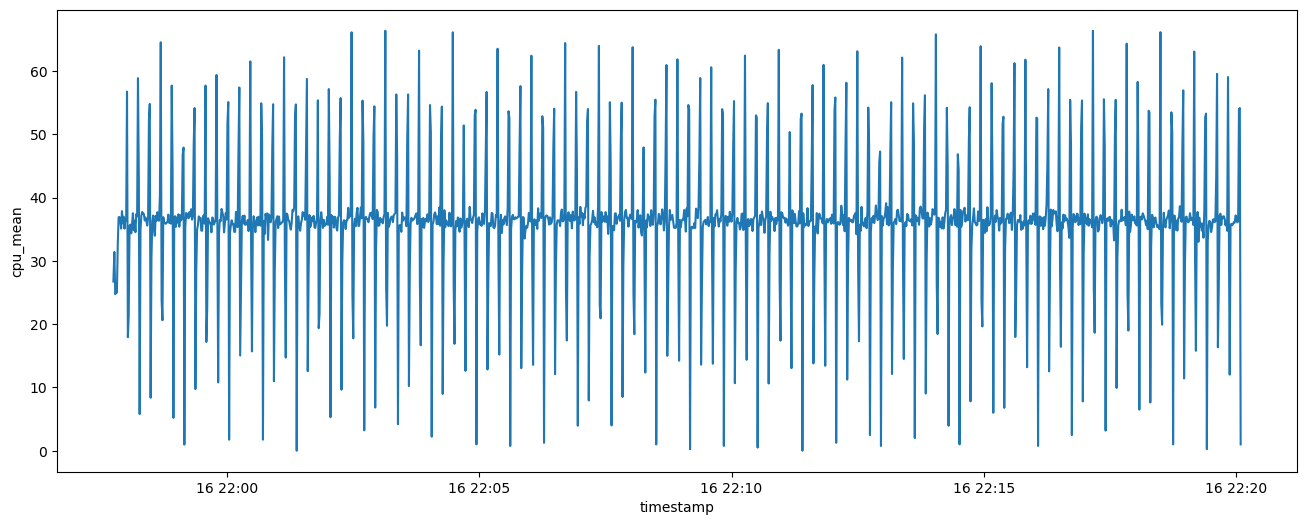

In [15]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

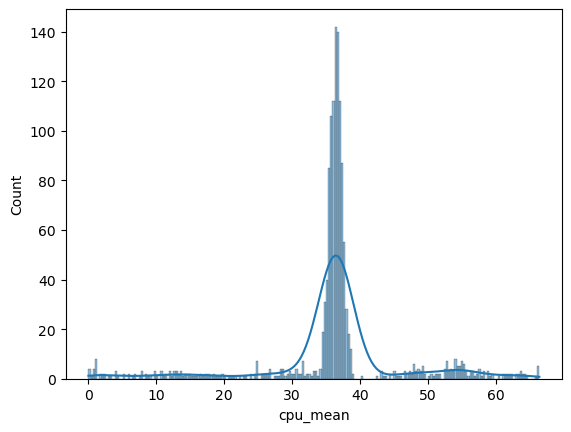

In [5]:
sns.histplot(data=dx21_cpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [19]:
dx21_ram = pd.read_csv(f'{x21_folder_path}/mem.csv')
dx21_ram['timestamp'] = dx21_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-16 21:57:43.799691,17002643456,16474030080,528613376,3.1,15627304960,810385408,356319232,42172416,923418624
1,2026-04-16 21:57:44.803736,17002643456,16446717952,555925504,3.3,15599992832,846348288,356319232,42172416,923418624
2,2026-04-16 21:57:45.806037,17002643456,16348971008,653672448,3.8,15502245888,913391616,356319232,42172416,923418624
3,2026-04-16 21:57:46.963622,17002643456,16296919040,705724416,4.2,15450193920,979959808,356319232,42172416,923418624
4,2026-04-16 21:57:47.967018,17002643456,16042311680,960331776,5.6,15195586560,1201553408,356319232,42172416,923418624


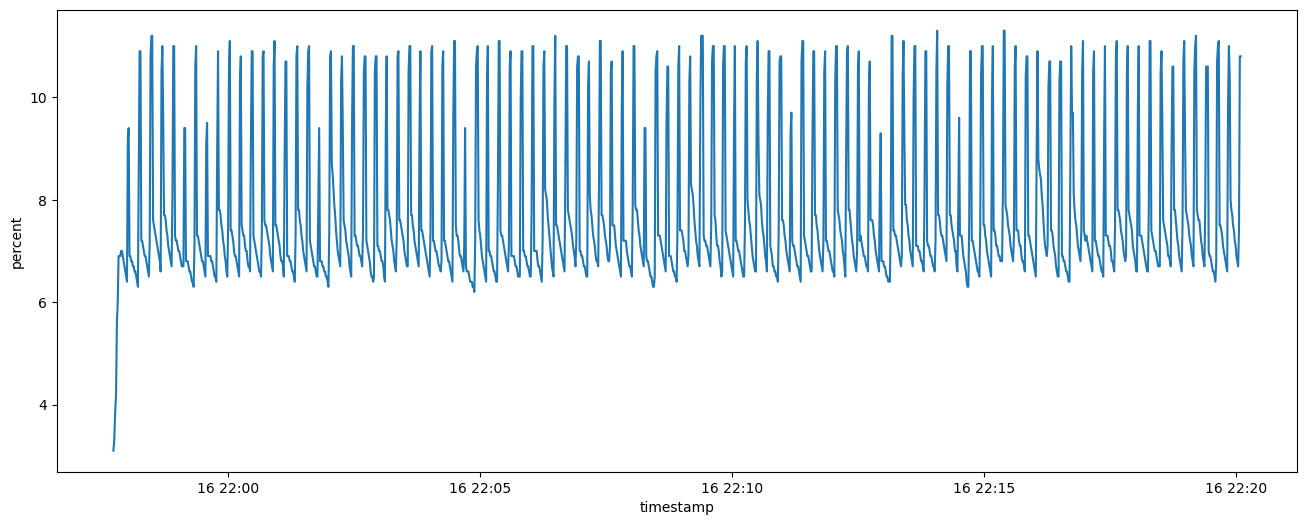

In [20]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

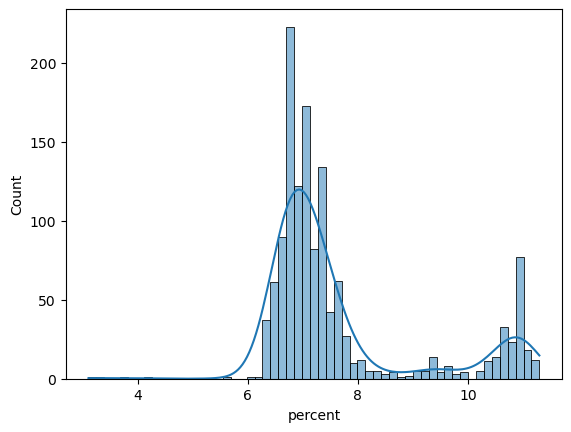

In [21]:
sns.histplot(data=dx21_ram, x="percent", kde=True)
plt.show()

In [22]:
dx21_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.338000e+03,1.338000e+03,1.338000e+03,1338.000000,1.338000e+03,1.338000e+03,1.338000e+03,1.338000e+03,1.338000e+03
mean,1.700264e+10,1.570138e+10,1.301268e+09,7.653961,1.485460e+10,1.412378e+09,3.563685e+08,4.222173e+07,9.234227e+08
std,0.000000e+00,2.449673e+08,2.449673e+08,1.442082,2.449704e+08,2.560356e+08,2.599980e+04,2.597648e+04,7.343705e+03
min,1.700264e+10,1.508575e+10,5.286134e+08,3.100000,1.423897e+10,8.103854e+08,3.563192e+08,4.217242e+07,9.234186e+08
25%,1.700264e+10,1.570247e+10,1.151615e+09,6.800000,1.485570e+10,1.286689e+09,3.563520e+08,4.220518e+07,9.234186e+08
50%,1.700264e+10,1.579476e+10,1.207886e+09,7.100000,1.494796e+10,1.288372e+09,3.563520e+08,4.220518e+07,9.234186e+08
75%,1.700264e+10,1.585103e+10,1.300177e+09,7.600000,1.500424e+10,1.296556e+09,3.563684e+08,4.222157e+07,9.234186e+08
max,1.700264e+10,1.647403e+10,1.916895e+09,11.300000,1.562730e+10,2.020655e+09,3.564339e+08,4.228710e+07,9.234514e+08


### Power

In [23]:
dx21_power = pd.read_csv(f'{x21_folder_path}/batch_10_1_3.csv')
dx21_power['timestamp'] = dx21_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx21_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-16T21:57:39.693192,0.0,5.1095,0.55515,2.8312,2026-04-16 21:57:39.693192
1,2026-04-16T21:57:40.711038,1.0,5.1092,0.55547,2.8328,2026-04-16 21:57:40.711038
2,2026-04-16T21:57:41.683088,2.0,5.1066,0.89602,4.5697,2026-04-16 21:57:41.683088
3,2026-04-16T21:57:42.700708,3.0,5.1078,0.90814,4.6315,2026-04-16 21:57:42.700708
4,2026-04-16T21:57:43.721567,4.0,5.1085,0.90637,4.6224,2026-04-16 21:57:43.721567


In [24]:
dx21_power = dx21_power.sort_values('timestamp')

# Time difference in hours
dx21_power['dt_hours'] = dx21_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx21_power['energy_Wh'] = dx21_power['Power[W]'] * dx21_power['dt_hours']

# Total energy
total_energy_Wh = dx21_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.117225572300778
Total energy (kWh): 0.002117225572300778


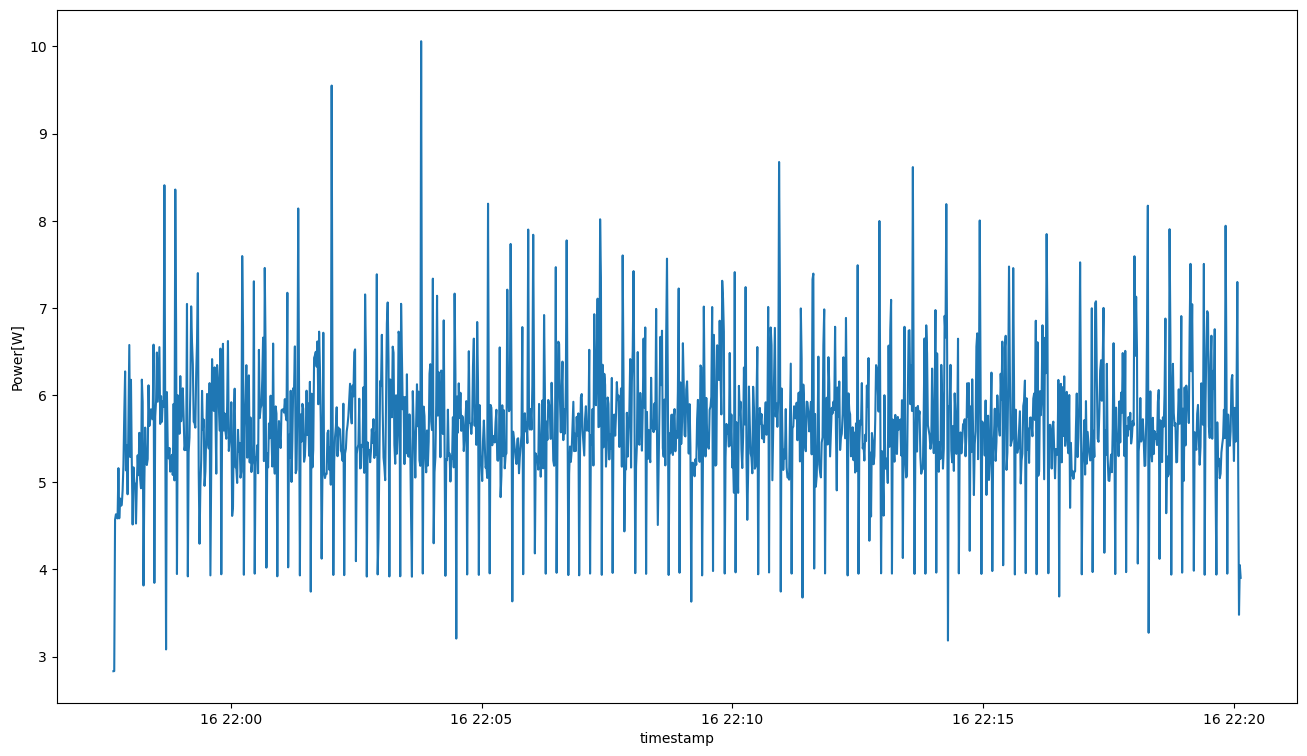

In [15]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=dx21_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

In [22]:
dx21_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1349.000000,1349.000000,1349.000000,1349.000000,1348.000000,1348.000000
mean,674.098443,5.108003,1.107611,5.651504,0.000278,0.001571
std,389.629276,0.005141,0.154503,0.788257,0.000006,0.000221
min,0.000000,5.086100,0.555150,2.831200,0.000269,0.000801
25%,337.100000,5.105600,1.035940,5.284200,0.000271,0.001467
50%,674.100000,5.108600,1.101680,5.621000,0.000283,0.001561
75%,1011.100000,5.110800,1.176410,6.000400,0.000284,0.001669
max,1348.200000,5.130000,1.976370,10.059700,0.000286,0.002734


## X2.2

passage_time: 05; interval: 1; window: 3 => 06 imgs (4 suited)

In [25]:
x22_folder_path = '../infra/reports/batch_2026-04-16T22:20:40.937381'

### Predict

In [26]:
from pandas import json_normalize
import json

with open(f'{x22_folder_path}/metrics.json') as f:
    x22_data = json.load(f)

load_model_duration = datetime.fromisoformat(x22_data['load_model_final']) - datetime.fromisoformat(x22_data['load_model_start'])
    
rows = []
for animal, v1 in x22_data['animals'].items():
    row = {
        'pid': x22_data['pid'],
        'load_model_start': datetime.fromisoformat(x22_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x22_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx22_metrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,1,2026-04-16 22:20:46.248035,2026-04-16 22:20:50.282963,2026-04-16 22:20:51.255623,2026-04-16 22:20:52.551351,2026-04-16 22:20:52.551434
1,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,2,2026-04-16 22:20:53.551532,2026-04-16 22:20:58.428853,2026-04-16 22:20:59.428127,2026-04-16 22:21:00.936352,2026-04-16 22:21:00.936423
2,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,3,2026-04-16 22:21:01.936525,2026-04-16 22:21:06.805617,2026-04-16 22:21:07.769706,2026-04-16 22:21:09.282376,2026-04-16 22:21:09.282444
3,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,4,2026-04-16 22:21:10.283912,2026-04-16 22:21:15.173257,2026-04-16 22:21:16.142647,2026-04-16 22:21:17.652322,2026-04-16 22:21:17.652388
4,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,5,2026-04-16 22:21:18.653818,2026-04-16 22:21:23.577522,2026-04-16 22:21:24.548050,2026-04-16 22:21:26.069576,2026-04-16 22:21:26.069647


In [27]:
dx22_metrics_v0['by_animal_lead_time'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['first_image_capture_time']
dx22_metrics_v0['by_animal_processing_delay'] = dx22_metrics_v0['weight_prediction_final'] - dx22_metrics_v0['weight_prediction_start']
dx22_metrics_v0['by_animal_latency'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['last_image_capture_time']

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,1,2026-04-16 22:20:46.248035,2026-04-16 22:20:50.282963,2026-04-16 22:20:51.255623,2026-04-16 22:20:52.551351,2026-04-16 22:20:52.551434,0 days 00:00:06.303399,0 days 00:00:01.295728,0 days 00:00:02.268471
1,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,2,2026-04-16 22:20:53.551532,2026-04-16 22:20:58.428853,2026-04-16 22:20:59.428127,2026-04-16 22:21:00.936352,2026-04-16 22:21:00.936423,0 days 00:00:07.384891,0 days 00:00:01.508225,0 days 00:00:02.507570
2,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,3,2026-04-16 22:21:01.936525,2026-04-16 22:21:06.805617,2026-04-16 22:21:07.769706,2026-04-16 22:21:09.282376,2026-04-16 22:21:09.282444,0 days 00:00:07.345919,0 days 00:00:01.512670,0 days 00:00:02.476827
3,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,4,2026-04-16 22:21:10.283912,2026-04-16 22:21:15.173257,2026-04-16 22:21:16.142647,2026-04-16 22:21:17.652322,2026-04-16 22:21:17.652388,0 days 00:00:07.368476,0 days 00:00:01.509675,0 days 00:00:02.479131
4,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,5,2026-04-16 22:21:18.653818,2026-04-16 22:21:23.577522,2026-04-16 22:21:24.548050,2026-04-16 22:21:26.069576,2026-04-16 22:21:26.069647,0 days 00:00:07.415829,0 days 00:00:01.521526,0 days 00:00:02.492125


In [28]:
collect_lead_time = dx22_metrics_v0['display_time'].max() - dx22_metrics_v0['first_image_capture_time'].min()
qtt = len(dx22_metrics_v0['animal'].unique())

dx22_metrics_v0['collect_lead_time'] = collect_lead_time
dx22_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,1,2026-04-16 22:20:46.248035,2026-04-16 22:20:50.282963,2026-04-16 22:20:51.255623,2026-04-16 22:20:52.551351,2026-04-16 22:20:52.551434,0 days 00:00:06.303399,0 days 00:00:01.295728,0 days 00:00:02.268471,0 days 00:13:55.834559,430.707245
1,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,2,2026-04-16 22:20:53.551532,2026-04-16 22:20:58.428853,2026-04-16 22:20:59.428127,2026-04-16 22:21:00.936352,2026-04-16 22:21:00.936423,0 days 00:00:07.384891,0 days 00:00:01.508225,0 days 00:00:02.507570,0 days 00:13:55.834559,430.707245
2,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,3,2026-04-16 22:21:01.936525,2026-04-16 22:21:06.805617,2026-04-16 22:21:07.769706,2026-04-16 22:21:09.282376,2026-04-16 22:21:09.282444,0 days 00:00:07.345919,0 days 00:00:01.512670,0 days 00:00:02.476827,0 days 00:13:55.834559,430.707245
3,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,4,2026-04-16 22:21:10.283912,2026-04-16 22:21:15.173257,2026-04-16 22:21:16.142647,2026-04-16 22:21:17.652322,2026-04-16 22:21:17.652388,0 days 00:00:07.368476,0 days 00:00:01.509675,0 days 00:00:02.479131,0 days 00:13:55.834559,430.707245
4,batch_2026-04-16T22:20:40.937381,2026-04-16 22:20:40.943797,2026-04-16 22:20:46.247918,0 days 00:00:05.304121,5,2026-04-16 22:21:18.653818,2026-04-16 22:21:23.577522,2026-04-16 22:21:24.548050,2026-04-16 22:21:26.069576,2026-04-16 22:21:26.069647,0 days 00:00:07.415829,0 days 00:00:01.521526,0 days 00:00:02.492125,0 days 00:13:55.834559,430.707245


In [31]:
# 6 imgs por animal
# 4 suited
# 6 * 100 animais / 13:55 min => 0.72 FPS
dx22_metrics_v0[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,100,100,100,1.000000e+02
mean,0 days 00:00:02.480709520,0 days 00:00:01.509296780,0 days 00:13:55.834559,4.307072e+02
std,0 days 00:00:00.023173694,0 days 00:00:00.022086571,0 days 00:00:00,2.856489e-13
min,0 days 00:00:02.268471,0 days 00:00:01.295728,0 days 00:13:55.834559,4.307072e+02
25%,0 days 00:00:02.475354750,0 days 00:00:01.508451,0 days 00:13:55.834559,4.307072e+02
50%,0 days 00:00:02.480360,0 days 00:00:01.510053,0 days 00:13:55.834559,4.307072e+02
75%,0 days 00:00:02.489084750,0 days 00:00:01.513359500,0 days 00:13:55.834559,4.307072e+02
max,0 days 00:00:02.507570,0 days 00:00:01.527206,0 days 00:13:55.834559,4.307072e+02


In [32]:
dx22_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:30.929678')

### CPU

In [33]:
dx22_cpu = pd.read_csv(f'{x22_folder_path}/cpu.csv')

dx22_cpu['timestamp'] = dx22_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_cpu['cpu_mean']  = dx22_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx22_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-16 22:20:41.940079,5.0,5.0,5.0,97.0,28.000
1,2026-04-16 22:20:43.099574,9.6,82.6,8.8,20.9,30.475
2,2026-04-16 22:20:44.109108,0.0,99.0,1.0,0.0,25.000
3,2026-04-16 22:20:45.109906,2.0,100.0,0.0,1.0,25.750
4,2026-04-16 22:20:46.110486,0.0,100.0,0.0,0.0,25.000


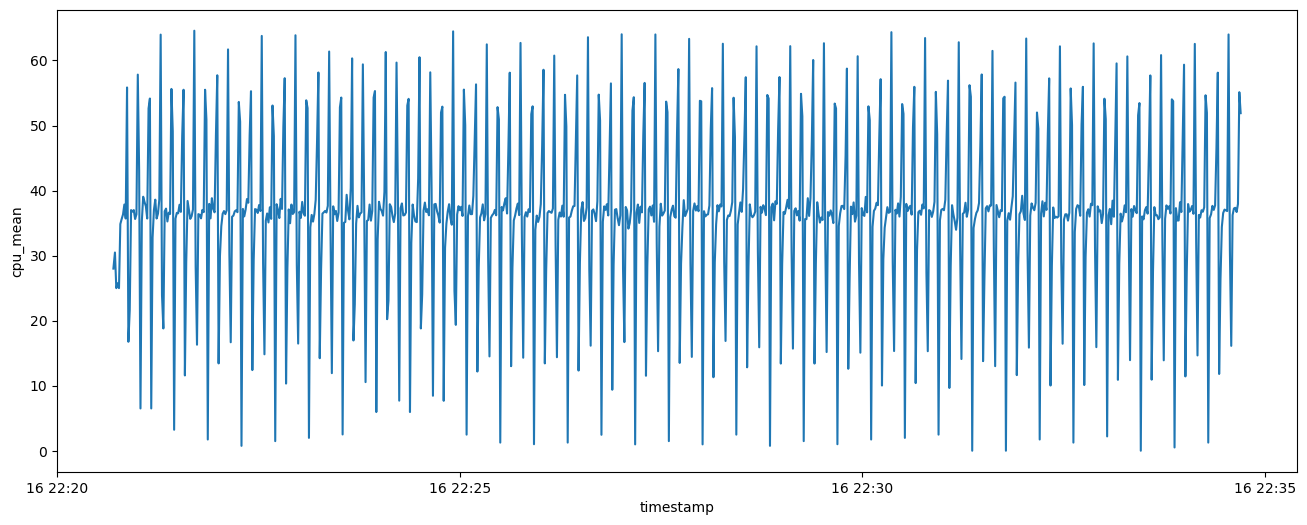

In [34]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

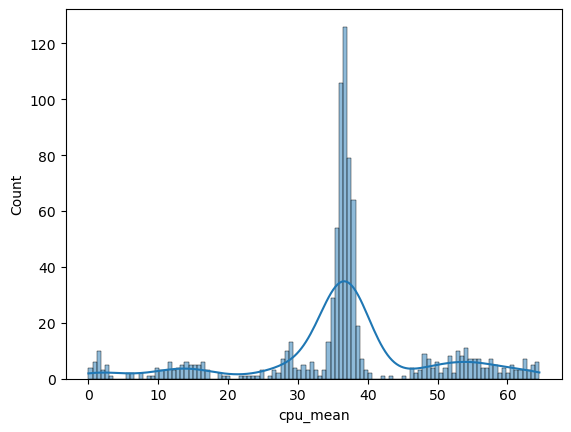

In [35]:
sns.histplot(data=dx22_cpu, x="cpu_mean", kde=True)
plt.show()

In [36]:
dx22_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,837.000000,837.000000,837.000000,837.000000,837.000000
mean,35.282557,39.472640,37.604659,33.343847,36.425926
std,20.662754,20.812018,20.429174,18.941462,12.893242
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,21.800000,20.800000,19.000000,35.250000
50%,30.300000,39.000000,36.400000,28.000000,36.700000
75%,51.000000,54.100000,53.200000,47.500000,38.075000
max,91.900000,100.000000,92.900000,97.000000,64.575000


### RAM

In [37]:
dx22_ram = pd.read_csv(f'{x22_folder_path}/mem.csv')
dx22_ram['timestamp'] = dx22_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-16 22:20:40.943690,17002643456,16433561600,569081856,3.3,15586410496,810237952,356728832,42303488,923729920
1,2026-04-16 22:20:41.947764,17002643456,16411426816,591216640,3.5,15564275712,847364096,356728832,42303488,923729920
2,2026-04-16 22:20:43.099388,17002643456,16333455360,669188096,3.9,15486304256,915783680,356728832,42303488,923729920
3,2026-04-16 22:20:44.099735,17002643456,16260153344,742490112,4.4,15413002240,984858624,356728832,42303488,923729920
4,2026-04-16 22:20:45.102170,17002643456,16000876544,1001766912,5.9,15153725440,1204338688,356728832,42303488,923729920


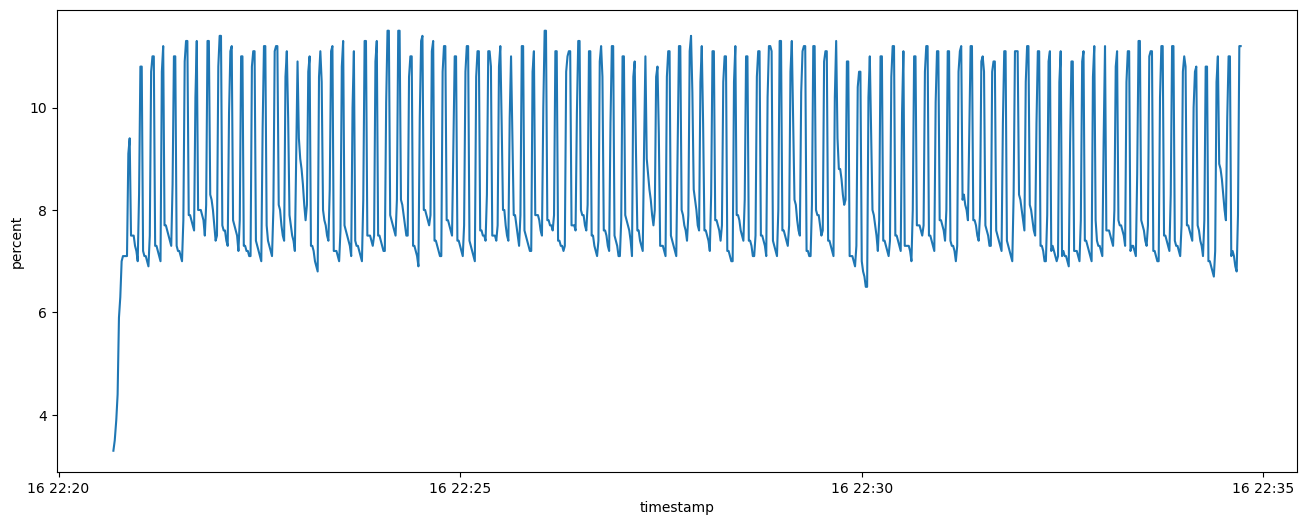

In [38]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

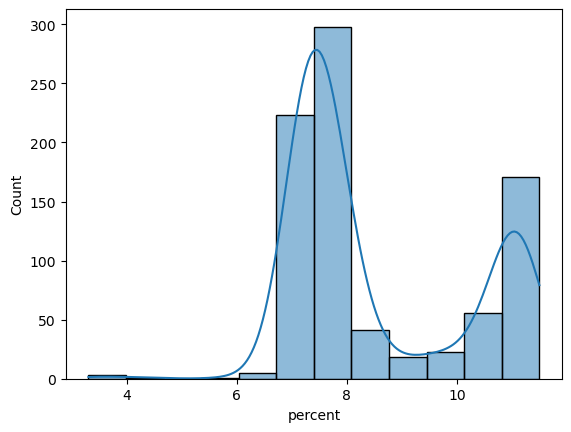

In [39]:
sns.histplot(data=dx22_ram, x="percent", kde=True)
plt.show()

In [40]:
dx22_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,8.400000e+02,8.400000e+02,8.400000e+02,840.000000,8.400000e+02,8.400000e+02,8.400000e+02,8.400000e+02,8.400000e+02
mean,1.700264e+10,1.555437e+10,1.448275e+09,8.518452,1.470718e+10,1.508893e+09,3.567655e+08,4.234031e+07,9.237300e+08
std,0.000000e+00,2.771838e+08,2.771838e+08,1.631968,2.771846e+08,3.136840e+08,1.677406e+04,1.682235e+04,3.391810e+03
min,1.700264e+10,1.504228e+10,5.690819e+08,3.300000,1.419511e+10,8.102380e+08,3.567288e+08,4.230349e+07,9.237299e+08
25%,1.700264e+10,1.520815e+10,1.244537e+09,7.300000,1.436097e+10,1.287504e+09,3.567452e+08,4.231987e+07,9.237299e+08
50%,1.700264e+10,1.569295e+10,1.309696e+09,7.700000,1.484575e+10,1.290568e+09,3.567616e+08,4.233626e+07,9.237299e+08
75%,1.700264e+10,1.575811e+10,1.794494e+09,10.600000,1.491093e+10,1.920733e+09,3.567780e+08,4.235264e+07,9.237299e+08
max,1.700264e+10,1.643356e+10,1.960362e+09,11.500000,1.558641e+10,2.030961e+09,3.567944e+08,4.236902e+07,9.238282e+08


### Power

In [43]:
dx22_power = pd.read_csv(f'{x22_folder_path}/batch_05_1_3.csv')
dx22_power['timestamp'] = dx22_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx22_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-16T22:20:37.176609,0.0,5.1091,0.58450,2.9809,2026-04-16 22:20:37.176609
1,2026-04-16T22:20:38.199087,1.0,5.1089,0.58486,2.9827,2026-04-16 22:20:38.199087
2,2026-04-16T22:20:39.174546,2.0,5.1086,0.94383,4.8135,2026-04-16 22:20:39.174546
3,2026-04-16T22:20:40.199348,3.0,5.1081,0.93242,4.7553,2026-04-16 22:20:40.199348
4,2026-04-16T22:20:41.174907,4.0,5.1076,1.00139,5.1070,2026-04-16 22:20:41.174907


In [45]:
dx22_power = dx22_power.sort_values('timestamp')

# Time difference in hours
dx22_power['dt_hours'] = dx22_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx22_power['energy_Wh'] = dx22_power['Power[W]'] * dx22_power['dt_hours']

# Total energy
total_energy_Wh = dx22_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.34064553141925
Total energy (kWh): 0.00134064553141925


In [47]:
dx22_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,850.000000,850.000000,850.000000,850.000000,849.000000,849.000000
mean,424.538588,5.107931,1.113578,5.682090,0.000278,0.001579
std,245.559231,0.005243,0.186265,0.949909,0.000006,0.000263
min,0.000000,5.081400,0.584500,2.980900,0.000270,0.000847
25%,212.250000,5.105800,1.032058,5.272400,0.000271,0.001464
50%,424.500000,5.108400,1.108845,5.654750,0.000283,0.001567
75%,636.850000,5.110600,1.217442,6.208875,0.000284,0.001724
max,849.100000,5.123000,1.881100,9.555900,0.000286,0.002712


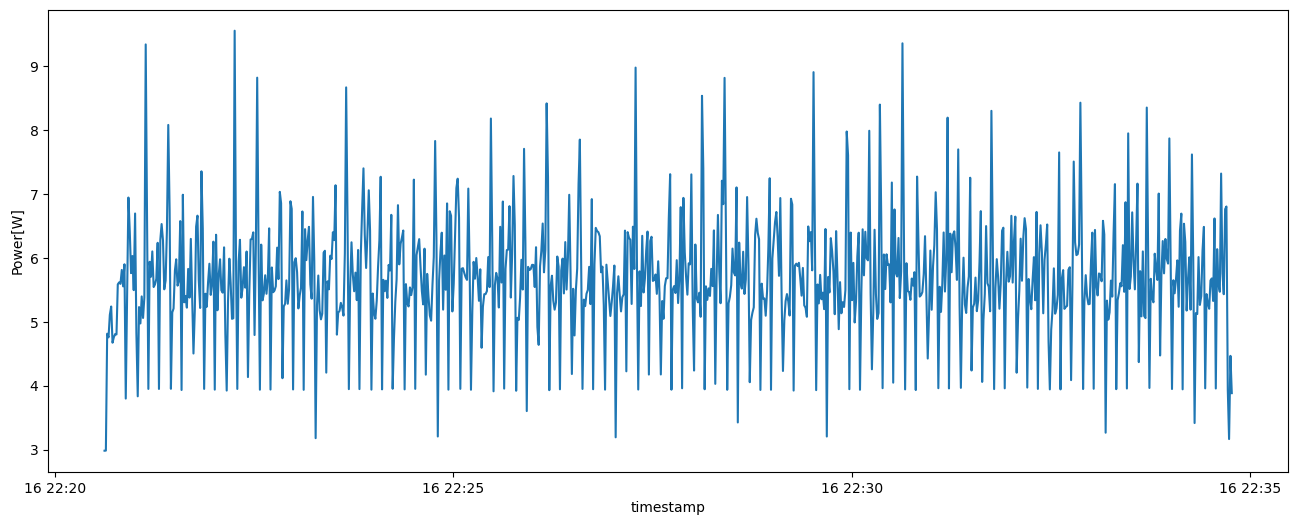

In [46]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.3

passage_time: 05; interval: 1; window: 2 => 06 imgs (3 suited)

In [48]:
x23_folder_path = '../infra/reports/batch_2026-04-16T22:35:32.949928'

### Predict

In [49]:
from pandas import json_normalize
import json

with open(f'{x23_folder_path}/metrics.json') as f:
    x23_data = json.load(f)

load_model_duration = datetime.fromisoformat(x23_data['load_model_final']) - datetime.fromisoformat(x23_data['load_model_start'])
    
rows = []
for animal, v1 in x23_data['animals'].items():
    row = {
        'pid': x23_data['pid'],
        'load_model_start': datetime.fromisoformat(x23_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x23_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx23_metrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,1,2026-04-16 22:35:38.312129,2026-04-16 22:35:42.435962,2026-04-16 22:35:43.432877,2026-04-16 22:35:44.553020,2026-04-16 22:35:44.553114
1,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,2,2026-04-16 22:35:45.555033,2026-04-16 22:35:49.610583,2026-04-16 22:35:50.605019,2026-04-16 22:35:51.718964,2026-04-16 22:35:51.719037
2,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,3,2026-04-16 22:35:52.720647,2026-04-16 22:35:56.783129,2026-04-16 22:35:57.784615,2026-04-16 22:35:58.870836,2026-04-16 22:35:58.870902
3,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,4,2026-04-16 22:35:59.872468,2026-04-16 22:36:04.865918,2026-04-16 22:36:05.869112,2026-04-16 22:36:06.986295,2026-04-16 22:36:06.986369
4,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,5,2026-04-16 22:36:07.987940,2026-04-16 22:36:12.009385,2026-04-16 22:36:13.015712,2026-04-16 22:36:14.109391,2026-04-16 22:36:14.109456


In [50]:
dx23_metrics_v0['by_animal_lead_time'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['first_image_capture_time']
dx23_metrics_v0['by_animal_processing_delay'] = dx23_metrics_v0['weight_prediction_final'] - dx23_metrics_v0['weight_prediction_start']
dx23_metrics_v0['by_animal_latency'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['last_image_capture_time']

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,1,2026-04-16 22:35:38.312129,2026-04-16 22:35:42.435962,2026-04-16 22:35:43.432877,2026-04-16 22:35:44.553020,2026-04-16 22:35:44.553114,0 days 00:00:06.240985,0 days 00:00:01.120143,0 days 00:00:02.117152
1,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,2,2026-04-16 22:35:45.555033,2026-04-16 22:35:49.610583,2026-04-16 22:35:50.605019,2026-04-16 22:35:51.718964,2026-04-16 22:35:51.719037,0 days 00:00:06.164004,0 days 00:00:01.113945,0 days 00:00:02.108454
2,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,3,2026-04-16 22:35:52.720647,2026-04-16 22:35:56.783129,2026-04-16 22:35:57.784615,2026-04-16 22:35:58.870836,2026-04-16 22:35:58.870902,0 days 00:00:06.150255,0 days 00:00:01.086221,0 days 00:00:02.087773
3,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,4,2026-04-16 22:35:59.872468,2026-04-16 22:36:04.865918,2026-04-16 22:36:05.869112,2026-04-16 22:36:06.986295,2026-04-16 22:36:06.986369,0 days 00:00:07.113901,0 days 00:00:01.117183,0 days 00:00:02.120451
4,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,5,2026-04-16 22:36:07.987940,2026-04-16 22:36:12.009385,2026-04-16 22:36:13.015712,2026-04-16 22:36:14.109391,2026-04-16 22:36:14.109456,0 days 00:00:06.121516,0 days 00:00:01.093679,0 days 00:00:02.100071


In [51]:
collect_lead_time = dx23_metrics_v0['display_time'].max() - dx23_metrics_v0['first_image_capture_time'].min()
qtt = len(dx23_metrics_v0['animal'].unique())

dx23_metrics_v0['collect_lead_time'] = collect_lead_time
dx23_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,1,2026-04-16 22:35:38.312129,2026-04-16 22:35:42.435962,2026-04-16 22:35:43.432877,2026-04-16 22:35:44.553020,2026-04-16 22:35:44.553114,0 days 00:00:06.240985,0 days 00:00:01.120143,0 days 00:00:02.117152,0 days 00:12:25.492665,482.902136
1,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,2,2026-04-16 22:35:45.555033,2026-04-16 22:35:49.610583,2026-04-16 22:35:50.605019,2026-04-16 22:35:51.718964,2026-04-16 22:35:51.719037,0 days 00:00:06.164004,0 days 00:00:01.113945,0 days 00:00:02.108454,0 days 00:12:25.492665,482.902136
2,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,3,2026-04-16 22:35:52.720647,2026-04-16 22:35:56.783129,2026-04-16 22:35:57.784615,2026-04-16 22:35:58.870836,2026-04-16 22:35:58.870902,0 days 00:00:06.150255,0 days 00:00:01.086221,0 days 00:00:02.087773,0 days 00:12:25.492665,482.902136
3,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,4,2026-04-16 22:35:59.872468,2026-04-16 22:36:04.865918,2026-04-16 22:36:05.869112,2026-04-16 22:36:06.986295,2026-04-16 22:36:06.986369,0 days 00:00:07.113901,0 days 00:00:01.117183,0 days 00:00:02.120451,0 days 00:12:25.492665,482.902136
4,batch_2026-04-16T22:35:32.949928,2026-04-16 22:35:32.955621,2026-04-16 22:35:38.311230,0 days 00:00:05.355609,5,2026-04-16 22:36:07.987940,2026-04-16 22:36:12.009385,2026-04-16 22:36:13.015712,2026-04-16 22:36:14.109391,2026-04-16 22:36:14.109456,0 days 00:00:06.121516,0 days 00:00:01.093679,0 days 00:00:02.100071,0 days 00:12:25.492665,482.902136


In [54]:
# 6 imgs por animal
# 3 suited
# 6 * 100 animais / 12:25 min => 0.80 FPS
dx23_metrics_v0[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,100,100,100,1.000000e+02
mean,0 days 00:00:02.139559660,0 days 00:00:01.141996090,0 days 00:12:25.492665,4.829021e+02
std,0 days 00:00:00.085346625,0 days 00:00:00.085916951,0 days 00:00:00,1.142596e-13
min,0 days 00:00:02.066975,0 days 00:00:01.074072,0 days 00:12:25.492665,4.829021e+02
25%,0 days 00:00:02.091449750,0 days 00:00:01.094540250,0 days 00:12:25.492665,4.829021e+02
50%,0 days 00:00:02.103700,0 days 00:00:01.104205,0 days 00:12:25.492665,4.829021e+02
75%,0 days 00:00:02.120704500,0 days 00:00:01.117486500,0 days 00:12:25.492665,4.829021e+02
max,0 days 00:00:02.334308,0 days 00:00:01.331926,0 days 00:12:25.492665,4.829021e+02


In [53]:
dx23_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:54.199609')

### CPU

In [55]:
dx23_cpu = pd.read_csv(f'{x23_folder_path}/cpu.csv')

dx23_cpu['timestamp'] = dx23_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_cpu['cpu_mean']  = dx23_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx23_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-16 22:35:33.953074,4.0,4.0,98.0,4.0,27.50
1,2026-04-16 22:35:35.139886,11.5,28.7,74.5,11.7,31.60
2,2026-04-16 22:35:36.166634,1.0,0.0,100.0,0.0,25.25
3,2026-04-16 22:35:37.172248,0.0,2.0,100.0,0.0,25.50
4,2026-04-16 22:35:38.176996,0.0,0.0,100.0,0.0,25.00


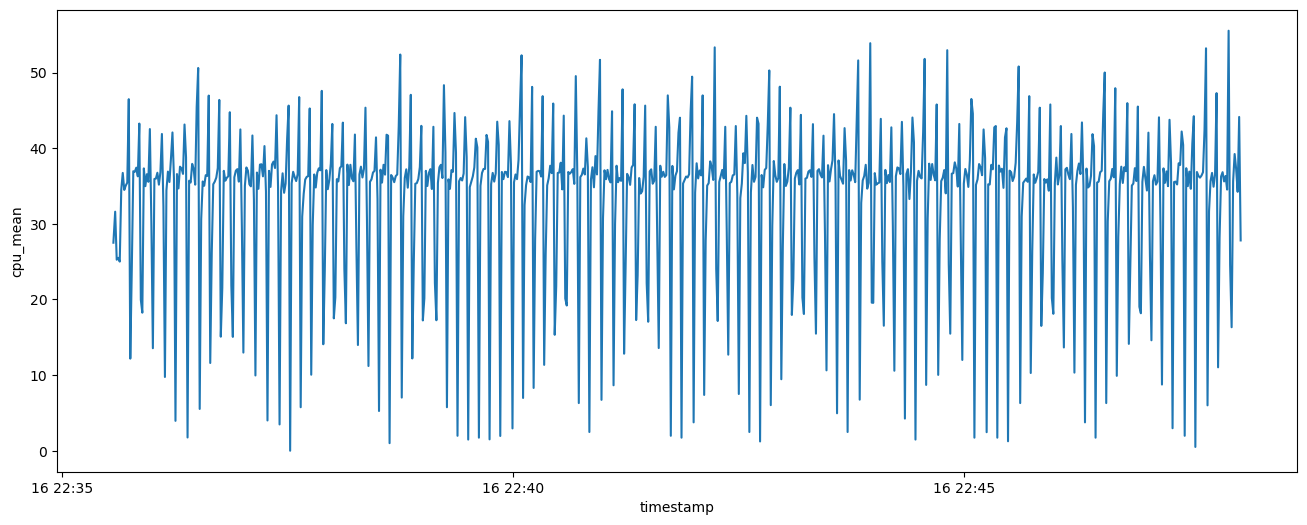

In [56]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

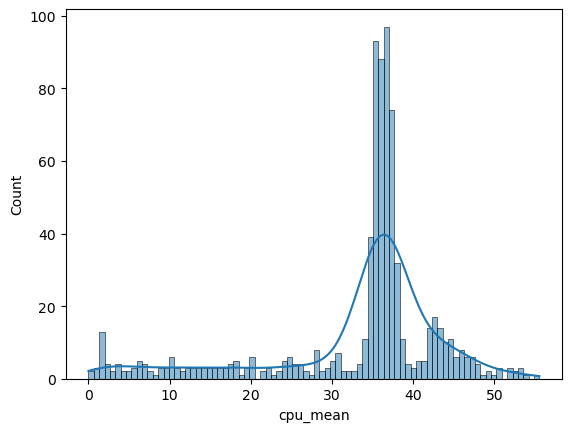

In [57]:
sns.histplot(data=dx23_cpu, x="cpu_mean", kde=True)
plt.show()

In [58]:
dx23_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,747.000000,747.000000,747.000000,747.000000,747.000000
mean,31.454351,34.768273,35.982329,30.684739,33.222423
std,19.361211,19.765387,20.557159,17.550677,10.902856
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.200000,19.500000,19.800000,18.150000,34.475000
50%,26.500000,32.000000,33.300000,27.400000,36.150000
75%,43.500000,48.250000,51.500000,41.700000,37.475000
max,90.900000,92.900000,100.000000,89.600000,55.525000


### RAM

In [59]:
dx23_ram = pd.read_csv(f'{x23_folder_path}/mem.csv')
dx23_ram['timestamp'] = dx23_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-16 22:35:32.955793,17002643456,16445374464,557268992,3.3,15597895680,810336256,357056512,42418176,923942912
1,2026-04-16 22:35:33.956814,17002643456,16427286528,575356928,3.4,15579807744,846364672,357056512,42418176,923942912
2,2026-04-16 22:35:34.980797,17002643456,16344956928,657686528,3.9,15497478144,914931712,357056512,42418176,923942912
3,2026-04-16 22:35:35.987111,17002643456,16290643968,711999488,4.2,15443165184,954875904,357056512,42418176,923942912
4,2026-04-16 22:35:36.988821,17002643456,16024240128,978403328,5.8,15176761344,1198866432,357056512,42418176,923942912


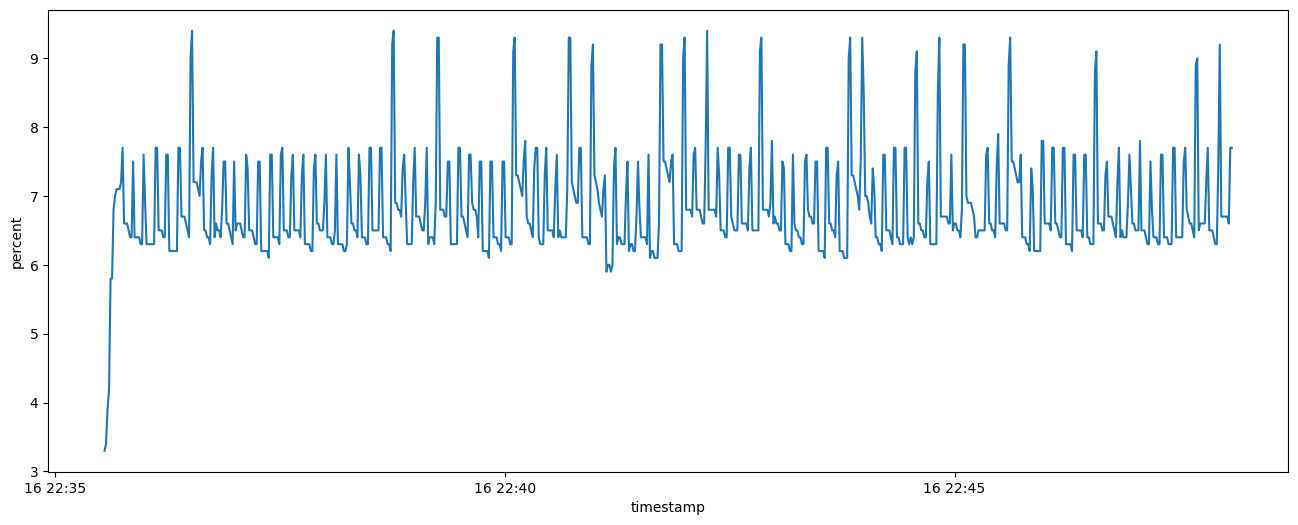

In [60]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

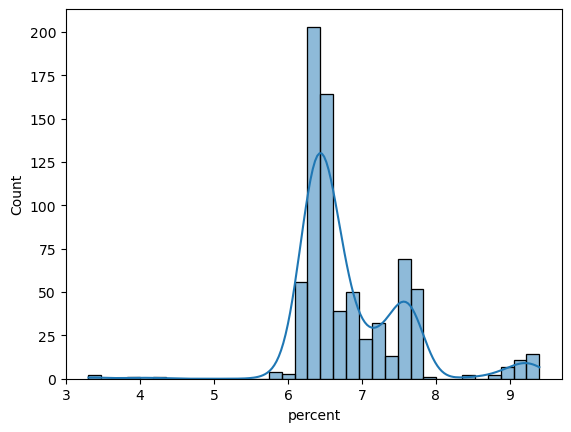

In [61]:
sns.histplot(data=dx23_ram, x="percent", kde=True)
plt.show()

In [62]:
dx23_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,7.490000e+02,7.490000e+02,7.490000e+02,749.000000,7.490000e+02,7.490000e+02,7.490000e+02,7.490000e+02,7.490000e+02
mean,1.700264e+10,1.584154e+10,1.161104e+09,6.831642,1.499402e+10,1.349820e+09,3.570967e+08,4.245840e+07,9.239433e+08
std,0.000000e+00,1.261240e+08,1.261240e+08,0.741638,1.261259e+08,1.270504e+08,2.184361e+04,2.156404e+04,4.047889e+03
min,1.700264e+10,1.540525e+10,5.572690e+08,3.300000,1.455774e+10,8.103363e+08,3.570565e+08,4.241818e+07,9.239429e+08
25%,1.700264e+10,1.576996e+10,1.083212e+09,6.400000,1.492245e+10,1.283408e+09,3.570893e+08,4.245094e+07,9.239429e+08
50%,1.700264e+10,1.588681e+10,1.115832e+09,6.600000,1.503932e+10,1.284833e+09,3.570893e+08,4.245094e+07,9.239429e+08
75%,1.700264e+10,1.591943e+10,1.232683e+09,7.200000,1.507194e+10,1.395376e+09,3.571057e+08,4.246733e+07,9.239429e+08
max,1.700264e+10,1.644537e+10,1.597391e+09,9.400000,1.559790e+10,1.755529e+09,3.571876e+08,4.250010e+07,9.240412e+08


### Power

In [63]:
dx23_power = pd.read_csv(f'{x23_folder_path}/batch_05_1_2.csv')
dx23_power['timestamp'] = dx23_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx23_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-16T22:35:28.113718,0.0,5.1085,0.58353,2.9760,2026-04-16 22:35:28.113718
1,2026-04-16T22:35:29.134799,1.0,5.1084,0.55832,2.8474,2026-04-16 22:35:29.134799
2,2026-04-16T22:35:30.111641,2.0,5.1083,0.60585,3.0898,2026-04-16 22:35:30.111641
3,2026-04-16T22:35:31.134667,3.0,5.1078,0.96466,4.9197,2026-04-16 22:35:31.134667
4,2026-04-16T22:35:32.110399,4.0,5.1075,0.95961,4.8940,2026-04-16 22:35:32.110399


In [64]:
dx23_power = dx23_power.sort_values('timestamp')

# Time difference in hours
dx23_power['dt_hours'] = dx23_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx23_power['energy_Wh'] = dx23_power['Power[W]'] * dx23_power['dt_hours']

# Total energy
total_energy_Wh = dx23_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.1507869012953333
Total energy (kWh): 0.0011507869012953333


In [65]:
dx23_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,760.000000,760.000000,760.000000,760.000000,759.000000,759.000000
mean,379.545658,5.107853,1.068707,5.452905,0.000278,0.001516
std,219.580397,0.004657,0.157719,0.805056,0.000006,0.000227
min,0.000000,5.089800,0.558320,2.847400,0.000269,0.000808
25%,189.750000,5.105575,1.018050,5.190525,0.000271,0.001436
50%,379.500000,5.108400,1.085210,5.536700,0.000283,0.001535
75%,569.350000,5.110500,1.156395,5.906600,0.000284,0.001645
max,759.100000,5.124700,1.659810,8.465000,0.000286,0.002397


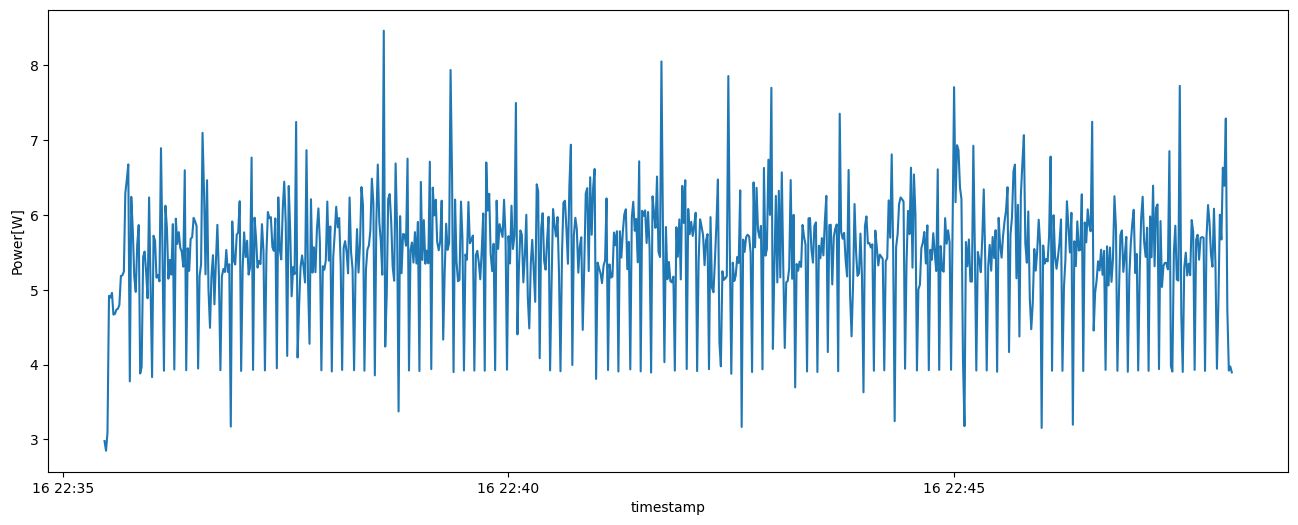

In [66]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.4

passage_time: 05; interval: 1; window: 1 => 06 imgs (1 suited)

In [87]:
x24_folder_path = '../infra/reports/batch_2026-04-16T22:48:40.347231'

### Predict

In [70]:
from pandas import json_normalize
import json

with open(f'{x24_folder_path}/metrics.json') as f:
    x24_data = json.load(f)

load_model_duration = datetime.fromisoformat(x24_data['load_model_final']) - datetime.fromisoformat(x24_data['load_model_start'])
    
rows = []
for animal, v1 in x24_data['animals'].items():
    row = {
        'pid': x24_data['pid'],
        'load_model_start': datetime.fromisoformat(x24_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x24_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx24_metrics_v0 = pd.DataFrame.from_dict(rows)[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx24_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time
0,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,1,2026-04-16 22:48:45.732359,2026-04-16 22:48:49.832596,2026-04-16 22:48:50.813526,2026-04-16 22:48:51.651318,2026-04-16 22:48:51.651402
1,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,2,2026-04-16 22:48:52.653066,2026-04-16 22:48:57.630158,2026-04-16 22:48:58.618274,2026-04-16 22:48:59.458104,2026-04-16 22:48:59.458175
2,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,3,2026-04-16 22:49:00.459850,2026-04-16 22:49:05.402375,2026-04-16 22:49:06.393648,2026-04-16 22:49:07.478591,2026-04-16 22:49:07.478655
3,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,4,2026-04-16 22:49:08.480328,2026-04-16 22:49:12.494018,2026-04-16 22:49:13.484145,2026-04-16 22:49:14.334104,2026-04-16 22:49:14.334169
4,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,5,2026-04-16 22:49:15.335749,2026-04-16 22:49:20.319965,2026-04-16 22:49:21.309091,2026-04-16 22:49:22.399808,2026-04-16 22:49:22.399885


In [71]:
dx24_metrics_v0['by_animal_lead_time'] = dx24_metrics_v0['display_time'] - dx24_metrics_v0['first_image_capture_time']
dx24_metrics_v0['by_animal_processing_delay'] = dx24_metrics_v0['weight_prediction_final'] - dx24_metrics_v0['weight_prediction_start']
dx24_metrics_v0['by_animal_latency'] = dx24_metrics_v0['display_time'] - dx24_metrics_v0['last_image_capture_time']

dx24_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,1,2026-04-16 22:48:45.732359,2026-04-16 22:48:49.832596,2026-04-16 22:48:50.813526,2026-04-16 22:48:51.651318,2026-04-16 22:48:51.651402,0 days 00:00:05.919043,0 days 00:00:00.837792,0 days 00:00:01.818806
1,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,2,2026-04-16 22:48:52.653066,2026-04-16 22:48:57.630158,2026-04-16 22:48:58.618274,2026-04-16 22:48:59.458104,2026-04-16 22:48:59.458175,0 days 00:00:06.805109,0 days 00:00:00.839830,0 days 00:00:01.828017
2,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,3,2026-04-16 22:49:00.459850,2026-04-16 22:49:05.402375,2026-04-16 22:49:06.393648,2026-04-16 22:49:07.478591,2026-04-16 22:49:07.478655,0 days 00:00:07.018805,0 days 00:00:01.084943,0 days 00:00:02.076280
3,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,4,2026-04-16 22:49:08.480328,2026-04-16 22:49:12.494018,2026-04-16 22:49:13.484145,2026-04-16 22:49:14.334104,2026-04-16 22:49:14.334169,0 days 00:00:05.853841,0 days 00:00:00.849959,0 days 00:00:01.840151
4,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,5,2026-04-16 22:49:15.335749,2026-04-16 22:49:20.319965,2026-04-16 22:49:21.309091,2026-04-16 22:49:22.399808,2026-04-16 22:49:22.399885,0 days 00:00:07.064136,0 days 00:00:01.090717,0 days 00:00:02.079920


In [72]:
collect_lead_time = dx24_metrics_v0['display_time'].max() - dx24_metrics_v0['first_image_capture_time'].min()
qtt = len(dx24_metrics_v0['animal'].unique())

dx24_metrics_v0['collect_lead_time'] = collect_lead_time
dx24_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx24_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,weight_prediction_start,weight_prediction_final,display_time,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,1,2026-04-16 22:48:45.732359,2026-04-16 22:48:49.832596,2026-04-16 22:48:50.813526,2026-04-16 22:48:51.651318,2026-04-16 22:48:51.651402,0 days 00:00:05.919043,0 days 00:00:00.837792,0 days 00:00:01.818806,0 days 00:13:08.649409,456.476599
1,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,2,2026-04-16 22:48:52.653066,2026-04-16 22:48:57.630158,2026-04-16 22:48:58.618274,2026-04-16 22:48:59.458104,2026-04-16 22:48:59.458175,0 days 00:00:06.805109,0 days 00:00:00.839830,0 days 00:00:01.828017,0 days 00:13:08.649409,456.476599
2,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,3,2026-04-16 22:49:00.459850,2026-04-16 22:49:05.402375,2026-04-16 22:49:06.393648,2026-04-16 22:49:07.478591,2026-04-16 22:49:07.478655,0 days 00:00:07.018805,0 days 00:00:01.084943,0 days 00:00:02.076280,0 days 00:13:08.649409,456.476599
3,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,4,2026-04-16 22:49:08.480328,2026-04-16 22:49:12.494018,2026-04-16 22:49:13.484145,2026-04-16 22:49:14.334104,2026-04-16 22:49:14.334169,0 days 00:00:05.853841,0 days 00:00:00.849959,0 days 00:00:01.840151,0 days 00:13:08.649409,456.476599
4,batch_2026-04-16T22:48:40.347231,2026-04-16 22:48:40.351619,2026-04-16 22:48:45.731421,0 days 00:00:05.379802,5,2026-04-16 22:49:15.335749,2026-04-16 22:49:20.319965,2026-04-16 22:49:21.309091,2026-04-16 22:49:22.399808,2026-04-16 22:49:22.399885,0 days 00:00:07.064136,0 days 00:00:01.090717,0 days 00:00:02.079920,0 days 00:13:08.649409,456.476599


In [73]:
# 6 imgs por animal
# 1 suited
# 6 * 100 animais / 13:08 min => 0.80 FPS
dx24_metrics_v0[['by_animal_latency','by_animal_processing_delay','collect_lead_time','mean_throughput']].describe()

,by_animal_latency,by_animal_processing_delay,collect_lead_time,mean_throughput
count,100,100,100,1.000000e+02
mean,0 days 00:00:01.968832030,0 days 00:00:00.984690650,0 days 00:13:08.649409,4.564766e+02
std,0 days 00:00:00.116156145,0 days 00:00:00.119637172,0 days 00:00:00,3.999085e-13
min,0 days 00:00:01.812286,0 days 00:00:00.835208,0 days 00:13:08.649409,4.564766e+02
25%,0 days 00:00:01.832678750,0 days 00:00:00.842306250,0 days 00:13:08.649409,4.564766e+02
50%,0 days 00:00:02.056890500,0 days 00:00:01.079147,0 days 00:13:08.649409,4.564766e+02
75%,0 days 00:00:02.064876750,0 days 00:00:01.083389500,0 days 00:13:08.649409,4.564766e+02
max,0 days 00:00:02.083876,0 days 00:00:01.097954,0 days 00:13:08.649409,4.564766e+02


In [74]:
dx24_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:38.469065')

### CPU

In [75]:
dx24_cpu = pd.read_csv(f'{x24_folder_path}/cpu.csv')

dx24_cpu['timestamp'] = dx24_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx24_cpu['cpu_mean']  = dx24_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx24_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-16 22:48:41.352323,4.0,97.0,4.0,3.0,27.0
1,2026-04-16 22:48:42.526059,11.0,18.0,57.0,38.0,31.0
2,2026-04-16 22:48:43.546387,0.0,0.0,100.0,0.0,25.0
3,2026-04-16 22:48:44.550574,0.0,1.0,100.0,1.0,25.5
4,2026-04-16 22:48:45.555086,0.0,0.0,100.0,0.0,25.0


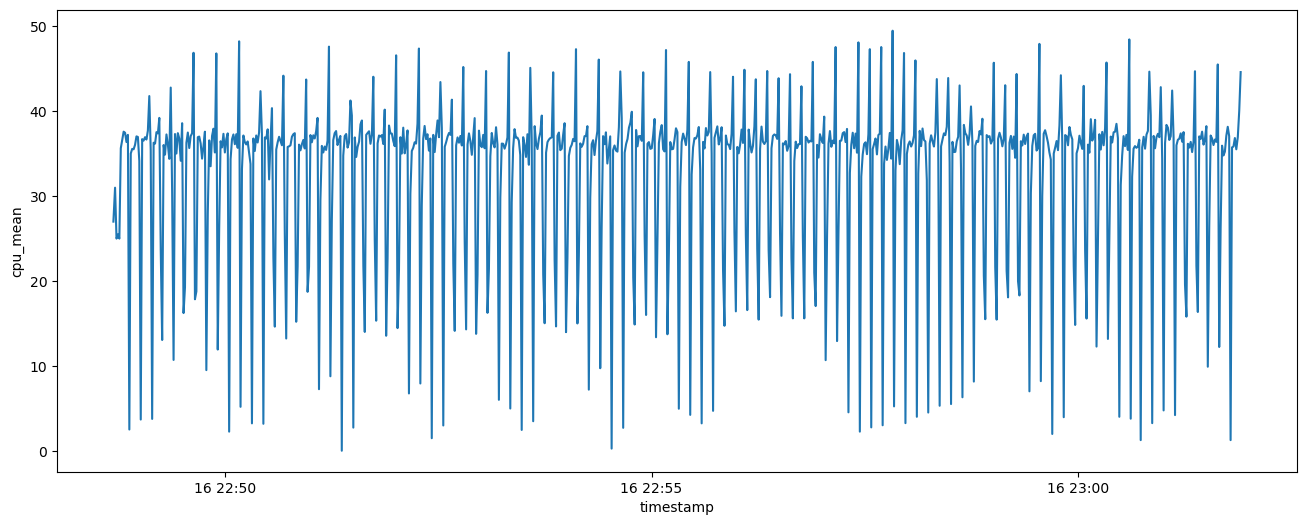

In [76]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx24_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

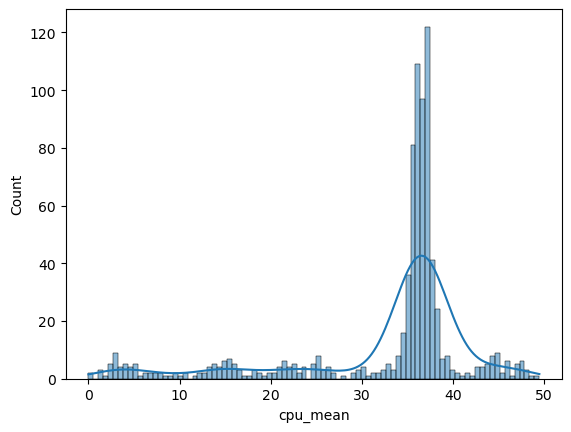

In [77]:
sns.histplot(data=dx24_cpu, x="cpu_mean", kde=True)
plt.show()

In [78]:
dx24_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,791.000000,791.000000,791.000000,791.000000,791.000000
mean,31.634387,35.027939,34.813654,29.640582,32.779140
std,19.035537,19.988427,19.552278,17.047613,10.071956
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.600000,20.000000,20.300000,18.600000,34.725000
50%,26.500000,32.300000,32.000000,25.300000,36.275000
75%,42.600000,49.000000,46.950000,39.600000,37.250000
max,93.900000,97.000000,100.000000,89.700000,49.500000


### RAM

In [79]:
dx24_ram = pd.read_csv(f'{x24_folder_path}/mem.csv')
dx24_ram['timestamp'] = dx24_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx24_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-16 22:48:40.351789,17002643456,16449683456,552960000,3.3,15601876992,810893312,357367808,42549248,924139520
1,2026-04-16 22:48:41.353003,17002643456,16425680896,576962560,3.4,15577858048,846315520,357384192,42549248,924155904
2,2026-04-16 22:48:42.531258,17002643456,16353427456,649216000,3.8,15505604608,915505152,357384192,42549248,924155904
3,2026-04-16 22:48:43.541924,17002643456,16281174016,721469440,4.2,15433351168,983564288,357384192,42549248,924155904
4,2026-04-16 22:48:44.543502,17002643456,16026320896,976322560,5.7,15178498048,1202028544,357384192,42582016,924155904


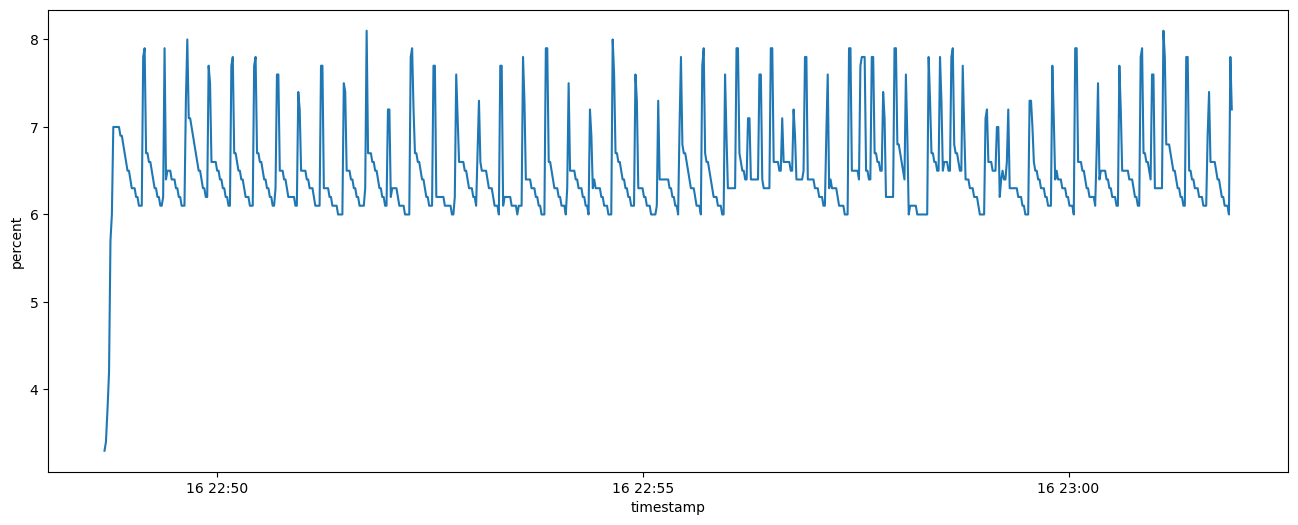

In [80]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx24_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

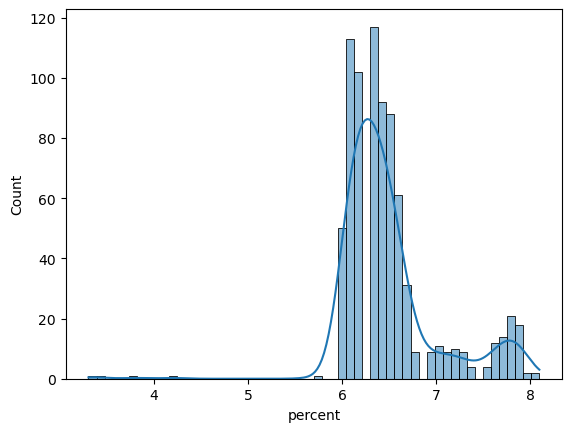

In [81]:
sns.histplot(data=dx24_ram, x="percent", kde=True)
plt.show()

In [82]:
dx24_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,7.930000e+02,7.930000e+02,7.930000e+02,793.000000,7.930000e+02,7.930000e+02,7.930000e+02,7.930000e+02,7.930000e+02
mean,1.700264e+10,1.589847e+10,1.104178e+09,6.493064,1.505060e+10,1.319764e+09,3.574266e+08,4.259177e+07,9.241559e+08
std,0.000000e+00,8.983067e+07,8.983067e+07,0.528782,8.983233e+07,7.510017e+07,8.905307e+03,8.537662e+03,5.818129e+02
min,1.700264e+10,1.562481e+10,5.529600e+08,3.300000,1.477696e+10,8.108933e+08,3.573678e+08,4.254925e+07,9.241395e+08
25%,1.700264e+10,1.588185e+10,1.051754e+09,6.200000,1.503397e+10,1.294516e+09,3.574170e+08,4.258202e+07,9.241559e+08
50%,1.700264e+10,1.592146e+10,1.081180e+09,6.400000,1.507361e+10,1.295729e+09,3.574333e+08,4.259840e+07,9.241559e+08
75%,1.700264e+10,1.595089e+10,1.120797e+09,6.600000,1.510302e+10,1.297564e+09,3.574333e+08,4.259840e+07,9.241559e+08
max,1.700264e+10,1.644968e+10,1.377829e+09,8.100000,1.560188e+10,1.542242e+09,3.574333e+08,4.259840e+07,9.241559e+08


### Power

In [83]:
dx24_power = pd.read_csv(f'{x24_folder_path}/batch_05_1_1.csv')
dx24_power['timestamp'] = dx24_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx24_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-16T22:48:36.961327,0.0,5.1098,0.56662,2.8897,2026-04-16 22:48:36.961327
1,2026-04-16T22:48:37.929299,1.0,5.1094,0.59520,3.0355,2026-04-16 22:48:37.929299
2,2026-04-16T22:48:38.950381,2.0,5.1091,0.92479,4.7164,2026-04-16 22:48:38.950381
3,2026-04-16T22:48:39.926421,3.0,5.1089,0.92189,4.7016,2026-04-16 22:48:39.926421
4,2026-04-16T22:48:40.945364,4.0,5.1089,0.92434,4.7141,2026-04-16 22:48:40.945364


In [84]:
dx24_power = dx24_power.sort_values('timestamp')

# Time difference in hours
dx24_power['dt_hours'] = dx24_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx24_power['energy_Wh'] = dx24_power['Power[W]'] * dx24_power['dt_hours']

# Total energy
total_energy_Wh = dx24_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.2154925810987223
Total energy (kWh): 0.0012154925810987222


In [85]:
dx24_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,802.000000,802.000000,802.000000,802.000000,801.000000,801.000000
mean,400.554489,5.108582,1.069727,5.458910,0.000278,0.001517
std,231.704731,0.004373,0.156860,0.800232,0.000006,0.000224
min,0.000000,5.091700,0.566620,2.889700,0.000269,0.000816
25%,200.250000,5.106600,1.021922,5.212450,0.000271,0.001435
50%,400.600000,5.109000,1.082660,5.525000,0.000283,0.001530
75%,600.850000,5.110900,1.157615,5.906075,0.000283,0.001642
max,801.100000,5.122200,1.567800,7.995700,0.000285,0.002269


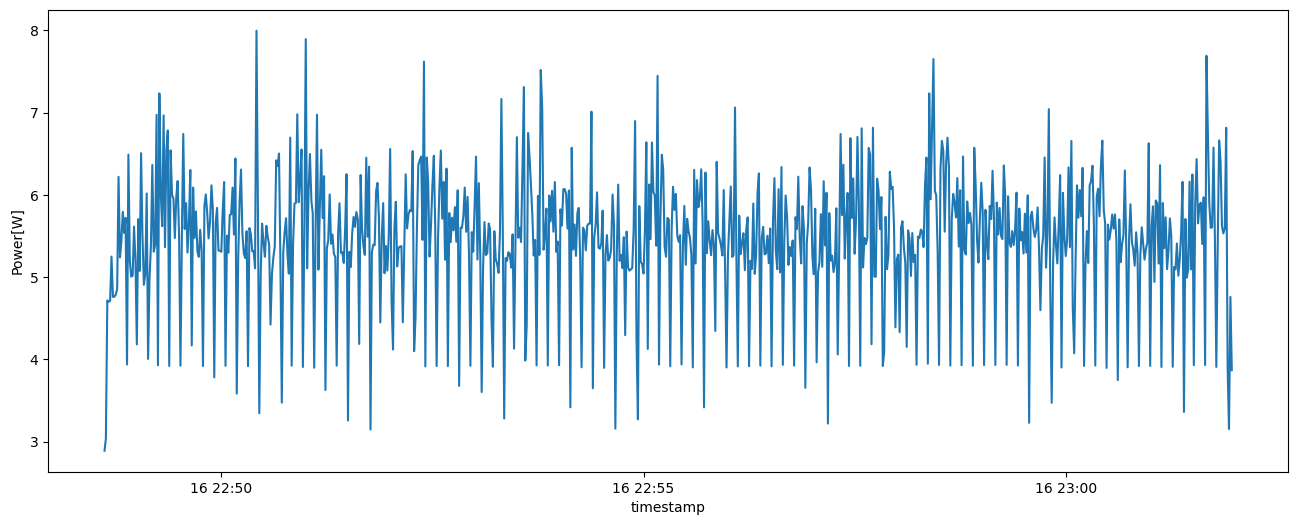

In [86]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx24_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()